**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

Mentoría 17 - Inventarios Forestales Nacionales, calculo de biomasa y evaluación del estado de los bosques nativos.

GRUPO 1

Mentor:

Anibal Cuchietti

*Edición 2025*

----

### Práctico 2 de análisis exploratorio y curación de datos

Determinar datos extraños con metodos bivariados (bagplot) de las variables medidas a los arboles de las unidades de muestreo del inventario nacional. Determinar datos faltantes y completar la base de datos.

In [184]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import missingno as msno

from sklearn.impute import KNNImputer


### Data frame con datos generales:

In [185]:
url = 'https://github.com/poggiogu/DiploDatos2025_Mentoria_17/raw/refs/heads/master/Data/2INBN_Tabla_general_2021.csv'
df_general = pd.read_csv(url, encoding='latin1')
#df_general.head(3)

In [186]:
columnas_num = df_general.select_dtypes(include=['number']).columns.tolist()
columnas_cat = df_general.select_dtypes(exclude=['number']).columns.tolist()

print("Columnas numéricas:", columnas_num)
print("Columnas categóricas:", columnas_cat)

Columnas numéricas: ['UM_ID_UM', 'PROVINCIA', 'MEDIA_ALTURA_UM_EST', 'SUMA_DAP_X_UM', 'AREA_BASAL_UM_HA', 'VOL_M3_HA', 'CANTIDAD_IND_VIVOS_UM', 'CANTIDAD_IND_VIVOS_HA', 'PORCENTAJE_COB_3', 'PORCENTAJE_COB_7', 'PORCENTAJE_COB_TOTAL', 'PORCENTAJE_COB_ARBUSTIVA', 'PORCENTAJE_COB_INFERIOR', 'MEDIA_ALT_TOCONES', 'MEDIA_DAB_TOCONES', 'CANTIDAD_TOCONES_X_UM', 'CANTIDAD_TOCONES_X_HA', 'REGENERACION_UM', 'REGENERACION_HA', 'LONGITUD_GRILLA', 'LATITUD_GRILLA', 'LONGITUD_INSTALACION', 'LATITUD_INSTALACION', 'ALTITUD', 'FECHA_UM_ANIO', 'FECHA_UM_MES']
Columnas categóricas: ['REGION_OFC', 'SUBREG', 'PENDIENTE_CATEGORIA', 'EXPOSICION', 'OTBN_CATEGORIA', 'TIPO_PAISAJE', 'SALINIDAD_PRESENCIA', 'INCENDIOS_RASTROS', 'PASTOREO_PRESENCIA', 'GANADO_BOVINO', 'GANADO_OVINO', 'GANADO_CAPRINO', 'GANADO_EQUINO', 'GANADO_OTRO', 'GANADO_OTRO_TIPO', 'EROSION_PRESENCIA', 'EROSION_FISICA_PRESENCIA', 'EROSION_EOLICA_PRESENCIA', 'EROSION_HIDRICA_PRESENCIA', 'PFNM_PRESENCIA_RESUMEN', 'PFNM_REGISTRO_1', 'PFNM_REGISTRO_2

In [187]:
# creación de un DF copia para poder alterar y realizar comparaciones en bloques de código posteriores:
df_general_c = df_general.copy()

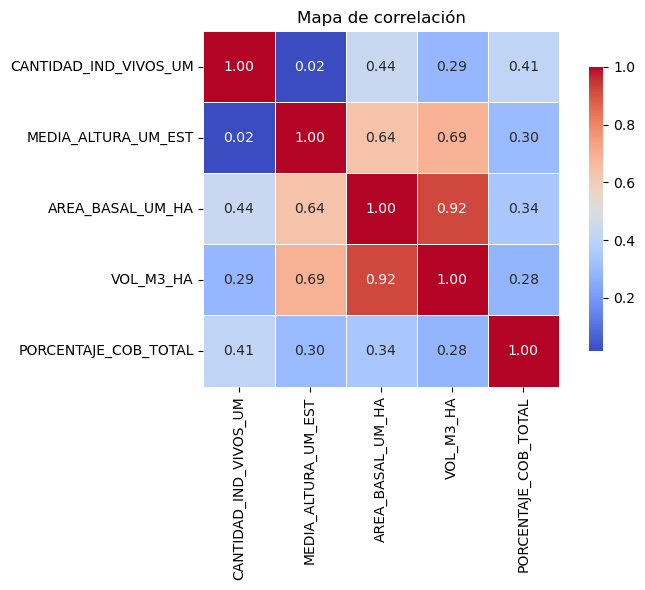

In [188]:

variables = ['CANTIDAD_IND_VIVOS_UM', 'MEDIA_ALTURA_UM_EST', 'AREA_BASAL_UM_HA', 
             'VOL_M3_HA', 'PORCENTAJE_COB_TOTAL']

# Eliminar filas con valores faltantes en estas columnas
df_corr = df_general_c[variables].dropna()

# Calcular la matriz de correlación
corr_matrix = df_corr.corr(method='pearson')  # podés cambiar a 'spearman' si querés

# Crear el mapa de calor
plt.figure(figsize=(8,6))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title("Mapa de correlación")
plt.tight_layout()
plt.show()

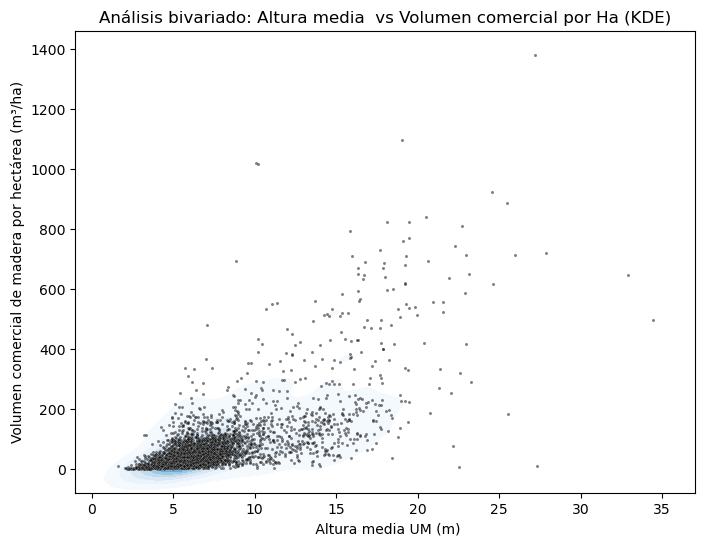

In [189]:
# Eliminar nulos
df = df_general_c.copy()
datos = df[['MEDIA_ALTURA_UM_EST', 'VOL_M3_HA']].dropna()

# Gráfico de densidad bivariada
plt.figure(figsize=(8,6))
sb.kdeplot(
    x=datos['MEDIA_ALTURA_UM_EST'], 
    y=datos['VOL_M3_HA'], 
    fill=True, 
    cmap='Blues', 
    thresh=0.05
)
sb.scatterplot(x=datos['MEDIA_ALTURA_UM_EST'], y=datos['VOL_M3_HA'], color='black', s=5, alpha=0.5)
plt.xlabel(" Altura media UM (m)")
plt.ylabel("Volumen comercial de madera por hectárea (m³/ha)")
plt.title("Análisis bivariado: Altura media  vs Volumen comercial por Ha (KDE)")
plt.show()

In [190]:
print("Cantidad de filas antes de eliminar outliers:", len(df))
df = df[~((df['MEDIA_ALTURA_UM_EST'] > 20) & (df['VOL_M3_HA'] > 400))]
print("Cantidad de filas después de eliminar outliers:", len(df))

Cantidad de filas antes de eliminar outliers: 3891
Cantidad de filas después de eliminar outliers: 3870


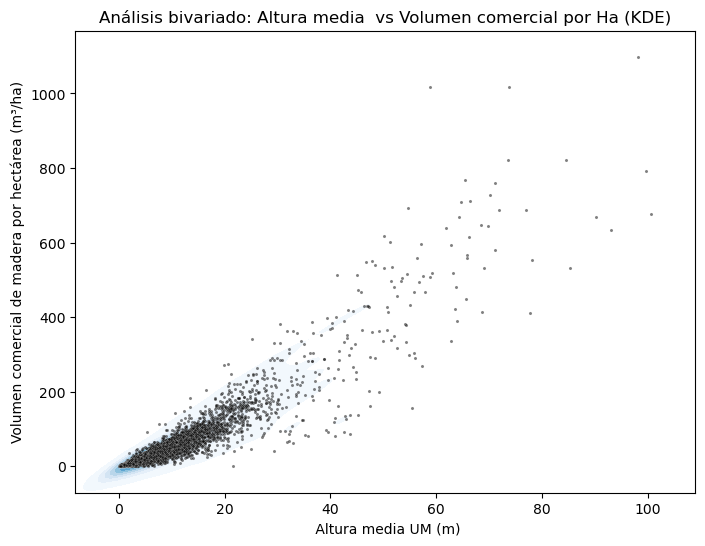

In [191]:
# Eliminar nulos
datos = df[['AREA_BASAL_UM_HA', 'VOL_M3_HA']].dropna()

# Gráfico de densidad bivariada
plt.figure(figsize=(8,6))
sb.kdeplot(
    x=datos['AREA_BASAL_UM_HA'], 
    y=datos['VOL_M3_HA'], 
    fill=True, 
    cmap='Blues', 
    thresh=0.05
)
sb.scatterplot(x=datos['AREA_BASAL_UM_HA'], y=datos['VOL_M3_HA'], color='black', s=5, alpha=0.5)
plt.xlabel(" Altura media UM (m)")
plt.ylabel("Volumen comercial de madera por hectárea (m³/ha)")
plt.title("Análisis bivariado: Altura media  vs Volumen comercial por Ha (KDE)")
plt.show()

In [192]:
from scipy.stats import gaussian_kde

# Elegí las dos variables
x = df['VOL_M3_HA']
y = df['AREA_BASAL_UM_HA']

# Eliminar filas con NaN en esas columnas
mask = x.notna() & y.notna()
x = x[mask]
y = y[mask]
df_clean = df[mask].copy()

# Crear matriz de puntos (2 x N)
xy = np.vstack([x, y])

# Estimar la densidad
kde = gaussian_kde(xy)

# Evaluar densidad en cada punto
densidades = kde(xy)

# Establecer umbral de densidad (por ejemplo, mantener el 95% con mayor densidad)
umbral = np.percentile(densidades, 5)  # el 5% con menor densidad será eliminado

# Filtrar los puntos que están dentro del contorno
df_filtrado = df_clean[densidades > umbral]

# (Opcional) Ver cuántos se eliminaron
print(f"Filas originales: {len(df)}")
print(f"Filas después de filtrar outliers: {len(df_filtrado)}")

Filas originales: 3870
Filas después de filtrar outliers: 3585


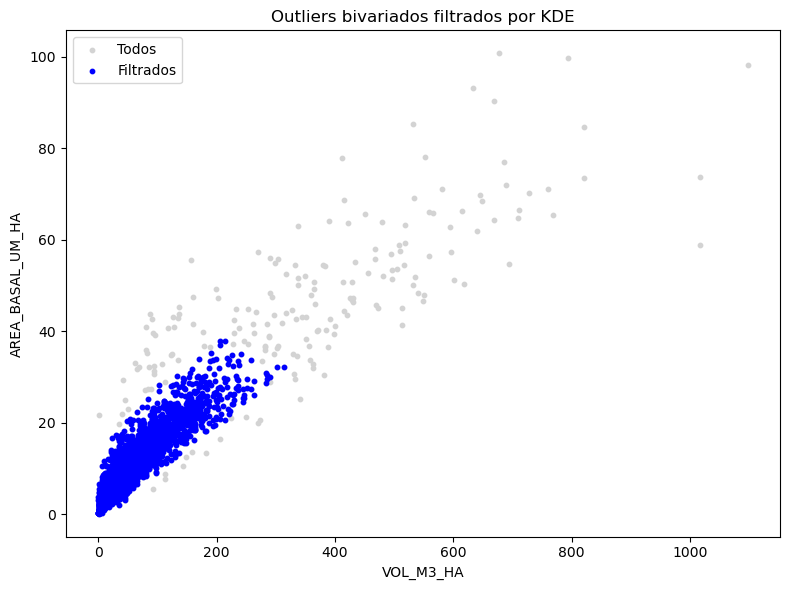

In [193]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, c='lightgray', s=10, label='Todos')
plt.scatter(df_filtrado['VOL_M3_HA'], df_filtrado['AREA_BASAL_UM_HA'],
            c='blue', s=10, label='Filtrados')
plt.xlabel('VOL_M3_HA')
plt.ylabel('AREA_BASAL_UM_HA')
plt.title('Outliers bivariados filtrados por KDE')
plt.legend()
plt.tight_layout()
plt.show()

----
----

### Data frame con datos de individuos:

In [194]:
url2 = 'https://raw.githubusercontent.com/poggiogu/DiploDatos2025_Mentoria_17/refs/heads/master/Data/data_individuos_pais_2021.csv'
df_individuos = pd.read_csv(url2, low_memory=False)
#df_individuos.head(3)
df_individuos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101229 entries, 0 to 101228
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   UM_ID_UM                    101229 non-null  int64  
 1   NO_INDIV                    101229 non-null  int64  
 2   PARCELA_CONCENTRICA         101229 non-null  object 
 3   ESPECIE_CORREGIDA           101229 non-null  object 
 4   REGION_OFC                  101229 non-null  object 
 5   SUBREG                      96093 non-null   object 
 6   ESTADO_INDIV                101229 non-null  object 
 7   ALTURA_TOTAL_M              101226 non-null  float64
 8   PROVINCIA                   101229 non-null  int64  
 9   COORDENADAS_GPS_LATITUDE2   101229 non-null  float64
 10  COORDENADAS_GPS_LONGITUDE2  101229 non-null  float64
 11  DAP_FINAL_M                 101229 non-null  float64
 12  ALTURA_TOTAL_EST            101229 non-null  float64
 13  VOL_M3        

In [195]:
columnas_num_ind= df_individuos.select_dtypes(include=['number']).columns.tolist()
columnas_cat_ind = df_individuos.select_dtypes(exclude=['number']).columns.tolist()

print("Columnas numéricas:", columnas_num_ind)
print("Columnas categóricas:", columnas_cat_ind)

Columnas numéricas: ['UM_ID_UM', 'NO_INDIV', 'ALTURA_TOTAL_M', 'PROVINCIA', 'COORDENADAS_GPS_LATITUDE2', 'COORDENADAS_GPS_LONGITUDE2', 'DAP_FINAL_M', 'ALTURA_TOTAL_EST', 'VOL_M3', 'VOL_M3_HA', 'DAP_CM', 'AREABASAL_CM2', 'AREABASAL_M2', 'DENSIDAD_MADERA', 'BIOMASA_KG', 'CARBONO_KG', 'BIOMASA_TN_HA', 'CARBONO_TN_HA', 'MEDIA_DIAM_COPA', 'DAB_FINAL_M', 'DIAMETRO_COPA_1', 'DIAMETRO_COPA_2', 'DAB_CM']
Columnas categóricas: ['PARCELA_CONCENTRICA', 'ESPECIE_CORREGIDA', 'REGION_OFC', 'SUBREG', 'ESTADO_INDIV', 'CLASE_DIAM', 'Ley_N1_06', 'Ley_N2_06']


In [196]:
# creación de un DF copia para poder alterar y realizar comparaciones en bloques de código posteriores:
df_individuos_c = df_individuos.copy()

##### Boxplots de variables con evidentes  outliers:

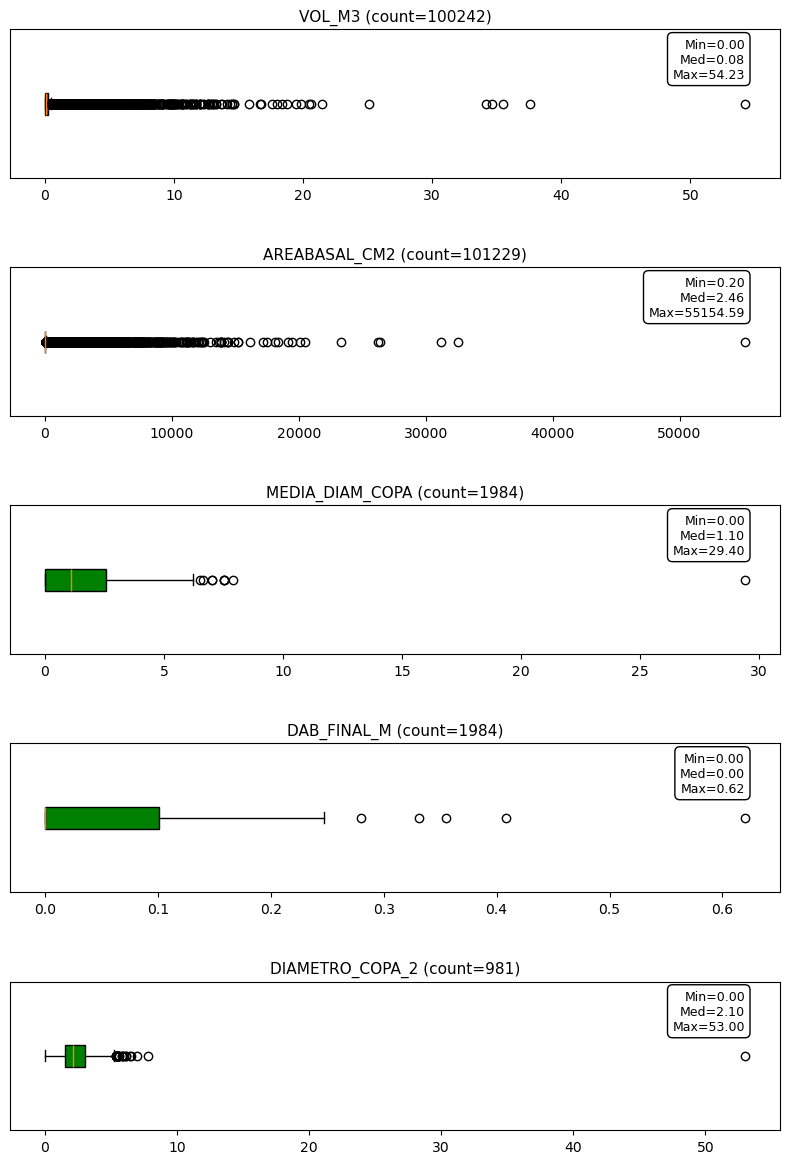

In [197]:
cols_ind = ['VOL_M3', 'AREABASAL_CM2', 'MEDIA_DIAM_COPA', 'DAB_FINAL_M', 'DIAMETRO_COPA_2']

n = len(cols_ind)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(8, 2.5 * n), sharex=False)

if n == 1:
    axes = [axes]

for i, col in enumerate(cols_ind):
    data = df_individuos_c[col].dropna()
    count = data.count()
    ax = axes[i]
    bp = ax.boxplot(data, vert=False, patch_artist=True) # vert=false ---> horizontal
    for box in bp['boxes']:
        box.set_facecolor('green')
    ax.set_title(f"{col} (count={count})", fontsize=11)
    ax.set_yticks([])
    percentiles = data.quantile([0.0, 0.5, 1.0])
    min_val = percentiles.loc[0.0]
    med_val = percentiles.loc[0.5]
    max_val = percentiles.loc[1.0]
    label_text = f"Min={min_val:.2f}\nMed={med_val:.2f}\nMax={max_val:.2f}"
    # Posición dentro del boxplot
    x_pos = max_val - (max_val - min_val) * 0.00  
    y_pos = 1.3  
    ax.text(
        x_pos, y_pos,
        label_text,
        ha='right', va='center',
        fontsize=9, color='black',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
    )

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.subplots_adjust(hspace=0.6)
plt.show()

##### Convertimos los outliers en valores NaN para imputarlos posteriormente:

In [198]:
# Reemplazar outliers por NaN (conservando los NaN preexistentes)
df_individuos_c.loc[df_individuos_c['VOL_M3'] >= 30, 'VOL_M3'] = np.nan
df_individuos_c.loc[df_individuos_c['AREABASAL_CM2'] >= 2000, 'AREABASAL_CM2'] = np.nan
df_individuos_c.loc[df_individuos_c['MEDIA_DIAM_COPA'] >= 10, 'MEDIA_DIAM_COPA'] = np.nan
df_individuos_c.loc[df_individuos_c['DAB_FINAL_M'] >= 0.3, 'DAB_FINAL_M'] = np.nan
df_individuos_c.loc[df_individuos_c['DIAMETRO_COPA_2'] >= 10, 'DIAMETRO_COPA_2'] = np.nan

# Crear df_filtrado conservando filas, solo modificando columnas con outliers
df_filtrado = df_individuos_c

# La cantidad de registros antes y despues del proceso debe ser la misma:
print(f'Cantidad de registros antes de aliminar outliers: {df_individuos_c.shape[0]}')
print(f'Cantidad de registros después de aliminar outliers (df_filtrado): {df_filtrado.shape[0]}')

Cantidad de registros antes de aliminar outliers: 101229
Cantidad de registros después de aliminar outliers (df_filtrado): 101229


##### Visualizamos valores Nulos en el dataset:

<Axes: >

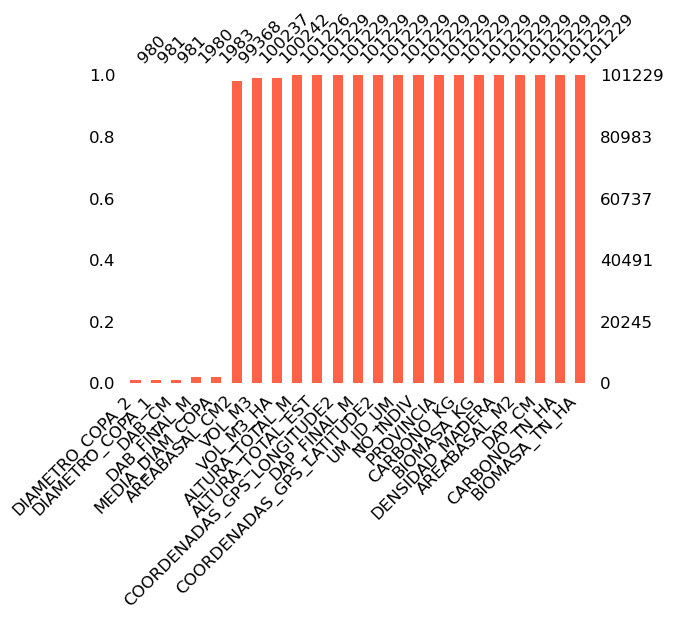

In [199]:
msno.bar(df_filtrado[columnas_num_ind],figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

Eliminamos las variables con muy baja cantidad de datos:

In [200]:
df_filtrado = df_filtrado.drop(columns=[
    'DIAMETRO_COPA_2',
    'DIAMETRO_COPA_1',
    'DAB_CM',
    'DAB_FINAL_M',
    'MEDIA_DIAM_COPA'
])

##### Aplicamos one hot encoding a variables categóricas con pocas clases individuales y y gran cantidad de datos: 

In [201]:
print(df_filtrado.nunique(dropna=True))

UM_ID_UM                       3815
NO_INDIV                        212
PARCELA_CONCENTRICA               2
ESPECIE_CORREGIDA               458
REGION_OFC                        7
SUBREG                           13
ESTADO_INDIV                      6
ALTURA_TOTAL_M                  942
PROVINCIA                        23
COORDENADAS_GPS_LATITUDE2      3781
COORDENADAS_GPS_LONGITUDE2     3788
DAP_FINAL_M                   10856
ALTURA_TOTAL_EST               1023
VOL_M3                        51943
VOL_M3_HA                     52316
DAP_CM                        11496
AREABASAL_CM2                 11649
AREABASAL_M2                  11892
DENSIDAD_MADERA                 168
BIOMASA_KG                    76750
CARBONO_KG                    76752
CLASE_DIAM                       13
BIOMASA_TN_HA                 77538
CARBONO_TN_HA                 77536
Ley_N1_06                         3
Ley_N2_06                        32
dtype: int64


##### Visualización de valores nulos antes aplicar onehot encoding y antes de la imputación de los mismos:

<Axes: >

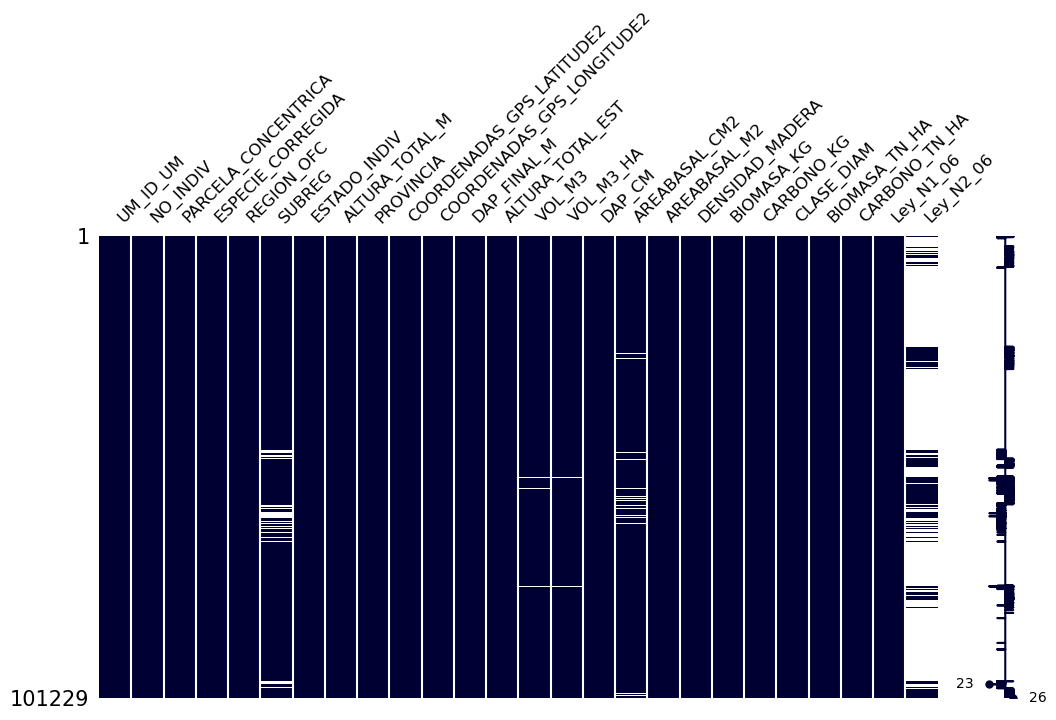

In [203]:
msno.matrix(df_filtrado,figsize=(12, 6), fontsize=12, color=[0,0,0.2])

In [ ]:
cols_onehot = [
'PARCELA_CONCENTRICA',
'REGION_OFC',    
'ESTADO_INDIV',   
'SUBREG',  
'CLASE_DIAM',
'Ley_N1_06'
]

In [212]:
df_ind_onehot = pd.get_dummies(df_filtrado, columns=cols_onehot, drop_first=False, dtype='int')
print(f'Cantidad de columnas antes del encoding: {df_filtrado.shape[1]}')
print(f'Cantidad de columnas después del encoding: {df_ind_onehot.shape[1]}')
print("")
print("Ejemplo después del onehot encoding: ")
df_ind_onehot[[col for col in df_ind_onehot.columns if 'PARCELA_CONCENTRICA' in col]].head()

Cantidad de columnas antes del encoding: 26
Cantidad de columnas después del encoding: 64

Ejemplo después del onehot encoding: 


,PARCELA_CONCENTRICA_A,PARCELA_CONCENTRICA_B
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


#### Imputamos con KNN los valores NULOS de todas las columnas numéricas:

In [ ]:
# Seleccionamos solo columnas numéricas otra vez después de aplicar onehot encoding
num_cols_onehot = df_ind_onehot.select_dtypes(include='number').columns
# Imputación con KNN
imputer = KNNImputer(n_neighbors=5)
df_ind_onehot[num_cols_onehot] = imputer.fit_transform(df_ind_onehot[num_cols_onehot])

##### Visualización después de la imputacón:

<Axes: >

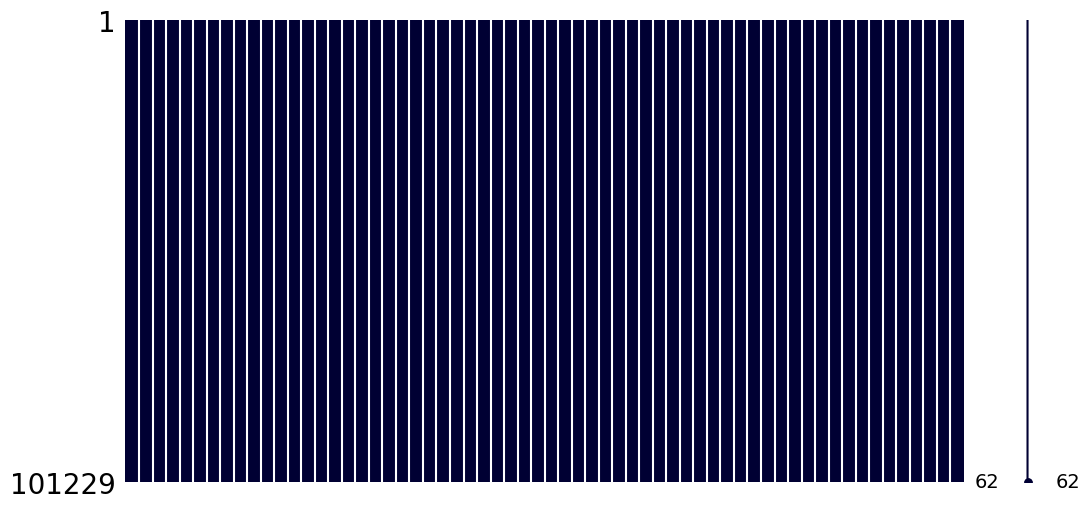

In [204]:
msno.matrix(df_ind_onehot[num_cols_onehot],figsize=(12, 6), color=[0,0,0.2])

In [205]:
df_ind_onehot.columns

Index(['UM_ID_UM', 'NO_INDIV', 'ESPECIE_CORREGIDA', 'ALTURA_TOTAL_M',
       'PROVINCIA', 'COORDENADAS_GPS_LATITUDE2', 'COORDENADAS_GPS_LONGITUDE2',
       'DAP_FINAL_M', 'ALTURA_TOTAL_EST', 'VOL_M3', 'VOL_M3_HA', 'DAP_CM',
       'AREABASAL_CM2', 'AREABASAL_M2', 'DENSIDAD_MADERA', 'BIOMASA_KG',
       'CARBONO_KG', 'BIOMASA_TN_HA', 'CARBONO_TN_HA', 'Ley_N2_06',
       'PARCELA_CONCENTRICA_A', 'PARCELA_CONCENTRICA_B', 'REGION_OFC_BAP',
       'REGION_OFC_DEL', 'REGION_OFC_ESP', 'REGION_OFC_MON', 'REGION_OFC_PCH',
       'REGION_OFC_SMI', 'REGION_OFC_STB', 'ESTADO_INDIV_-', 'ESTADO_INDIV_0',
       'ESTADO_INDIV_1', 'ESTADO_INDIV_2', 'ESTADO_INDIV_3', 'ESTADO_INDIV_4',
       'SUBREG_Bosque Andino Patagónico', 'SUBREG_Chaco Húmedo',
       'SUBREG_Chaco Semiárido', 'SUBREG_Chaco Serrano',
       'SUBREG_Chaco de Transición', 'SUBREG_Chaco Árido',
       'SUBREG_Delta del Río Paraná', 'SUBREG_Distrito del Algarrobo',
       'SUBREG_Distrito del Caldén', 'SUBREG_Distrito del Ñandubay',
  